In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [2]:
FILE_PATH = r'C:\Users\Acer Nitro 5\Desktop\Amazon sales\Amazon_Sale_Report.csv'

In [3]:
df = pd.read_csv(FILE_PATH)
df.head()

,index,Order ID,Date,Status,Fulfilment,Sales Channel,ship-service-level,Category,Size,Courier Status,...,currency,Amount,ship-city,ship-state,ship-postal-code,ship-country,B2B,fulfilled-by,New,PendingS;
0,0,405-8078784-5731545,04-30-22,Cancelled,Merchant,Amazon.in,Standard,T-shirt,S,On the Way,...,INR,647.62,MUMBAI,MAHARASHTRA,400081.0,IN,False,Easy Ship,NaN,;
1,1,171-9198151-1101146,04-30-22,Shipped - Delivered to Buyer,Merchant,Amazon.in,Standard,Shirt,3XL,Shipped,...,INR,406.00,BENGALURU,KARNATAKA,560085.0,IN,False,Easy Ship,NaN,;
2,2,404-0687676-7273146,04-30-22,Shipped,Amazon,Amazon.in,Expedited,Shirt,XL,Shipped,...,INR,329.00,NAVI MUMBAI,MAHARASHTRA,410210.0,IN,True,NaN,NaN,;
3,3,403-9615377-8133951,04-30-22,Cancelled,Merchant,Amazon.in,Standard,Blazzer,L,On the Way,...,INR,753.33,PUDUCHERRY,PUDUCHERRY,605008.0,IN,False,Easy Ship,NaN,;
4,4,407-1069790-7240320,04-30-22,Shipped,Amazon,Amazon.in,Expedited,Trousers,3XL,Shipped,...,INR,574.00,CHENNAI,TAMIL NADU,600073.0,IN,False,NaN,NaN,;


In [4]:
df['Date'] = pd.to_datetime(df['Date'], errors='coerce')

In [5]:
print("Null dates:", df['Date'].isna().sum())
print("Min date:", df['Date'].min())
print("Max date:", df['Date'].max())

Null dates: 1340
Min date: 2022-03-31 00:00:00
Max date: 2022-06-29 00:00:00


In [6]:
print(f"Loaded {len(df):,} orders")
print(f"Date range: {df['Date'].min().date()} to {df['Date'].max().date()}")

Loaded 128,976 orders
Date range: 2022-03-31 to 2022-06-29


In [7]:
# Data enrichment
df['delivered'] = df['Status'].isin(['Shipped - Delivered to Buyer', 'Shipped - Picked Up'])
df['cancelled'] = df['Status'] == 'Cancelled'
df['returned'] = df['Status'].str.contains('Return|Reject', na=False)

In [8]:
# Calculate revenue loss for cancelled orders
avg_amt = df['Amount'].mean()
df['revenue_loss'] = df.apply(lambda x: x['Amount'] if x['cancelled'] and pd.notna(x['Amount']) else 0, axis=1)

In [9]:
# Time metrics
df['days_old'] = (pd.Timestamp.now() - df['Date']).dt.days
df['week'] = df['Date'].dt.isocalendar().week
df['month'] = df['Date'].dt.strftime('%B')

In [10]:
# SLA Status Logic (Service Level Monitoring)
def get_sla_status(row):
    if row['Courier Status'] == 'Shipped':
        return 'Met SLA'
    
    if row['Courier Status'] == 'On the Way':
        if row['ship-service-level'] == 'Expedited' and row['days_old'] > 3:
            return 'Breached SLA'
        elif row['ship-service-level'] == 'Standard' and row['days_old'] > 5:
            return 'Breached SLA'
        else:
            return 'In Progress'
    
    return 'In Progress'

df['sla_status'] = df.apply(get_sla_status, axis=1)

In [11]:
# Identify orders that are delayed and might fail
df['at_risk'] = (
    (df['Courier Status'] == 'On the Way') &
    (df['days_old'] > 5)
)
print("Orders At Risk:", df['at_risk'].sum())

Orders At Risk: 6799


In [12]:
# City classification
tier1 = ['BENGALURU', 'HYDERABAD', 'MUMBAI', 'NEW DELHI', 'CHENNAI', 'PUNE']
tier2 = ['GURGAON', 'THANE', 'JAIPUR', 'AHMEDABAD', 'LUCKNOW']

In [13]:
def get_tier(city):
    if pd.isna(city):
        return 'Unknown'
    c = city.upper()
    if c in tier1:
        return 'Tier 1'
    elif c in tier2:
        return 'Tier 2'
    return 'Tier 3'

df['city_tier'] = df['ship-city'].apply(get_tier)

In [14]:
# Product grouping
def group_product(cat):
    if cat in ['T-shirt', 'Shirt']:
        return 'Casual'
    elif cat in ['Blazzer', 'Trousers']:
        return 'Formal'
    elif cat in ['Perfume', 'Watch', 'Wallet']:
        return 'Accessories'
    return 'Other'

df['product_group'] = df['Category'].apply(group_product)

In [15]:
# Fulfilment Efficiency Score (Operational Quality Indicator)
efficiency_map = {
    'Shipped - Delivered to Buyer': 100,
    'Shipped - Picked Up': 100,
    'Shipped': 80,
    'Shipped - Out for Delivery': 85,
    'Pending': 50,
    'Cancelled': 0,
    'Shipped - Returned to Seller': 20,
    'Shipped - Rejected by Buyer': 10,
    'Shipped - Lost in Transit': 0,
    'Shipped - Damaged': 5
}

df['fulfilment_score'] = df['Status'].map(efficiency_map).fillna(60)

In [16]:
# Customer Segmentation (Business Insight Layer)
def segment_customer(row):
    if row['B2B']:
        return 'B2B'
    
    if row['ship-service-level'] == 'Expedited' and row['Amount'] > 700:
        return 'Premium B2C'
    
    if row['ship-service-level'] == 'Expedited':
        return 'Standard B2C'
    
    return 'Value B2C'

df['customer_segment'] = df.apply(segment_customer, axis=1)

In [17]:
# Delivery Performance Classification
def delivery_tag(row):
    if row['delivered']:
        return 'Excellent'
    
    if row['at_risk']:
        return 'At Risk'
    
    if row['cancelled'] or row['returned']:
        return 'Failed'
    
    return 'In Progress'

df['delivery_status'] = df.apply(delivery_tag, axis=1)

In [18]:
df[['sla_status', 'fulfilment_score', 
    'customer_segment', 'delivery_status']].head()

,sla_status,fulfilment_score,customer_segment,delivery_status
0,Breached SLA,0.0,Value B2C,At Risk
1,Met SLA,100.0,Value B2C,Excellent
2,Met SLA,80.0,B2B,In Progress
3,Breached SLA,0.0,Value B2C,At Risk
4,Met SLA,80.0,Standard B2C,In Progress


In [19]:
# Success flag
df['success'] = df['Status'].isin(['Shipped', 'Shipped - Delivered to Buyer', 'Shipped - Picked Up']).astype(int)

In [20]:
print(f"Dataset enriched: {df.shape[0]:,} rows x {df.shape[1]} columns")

Dataset enriched: 128,976 rows x 36 columns


In [21]:
# ============================================================================
# ANALYSIS 1: Weekly Trends
# ============================================================================

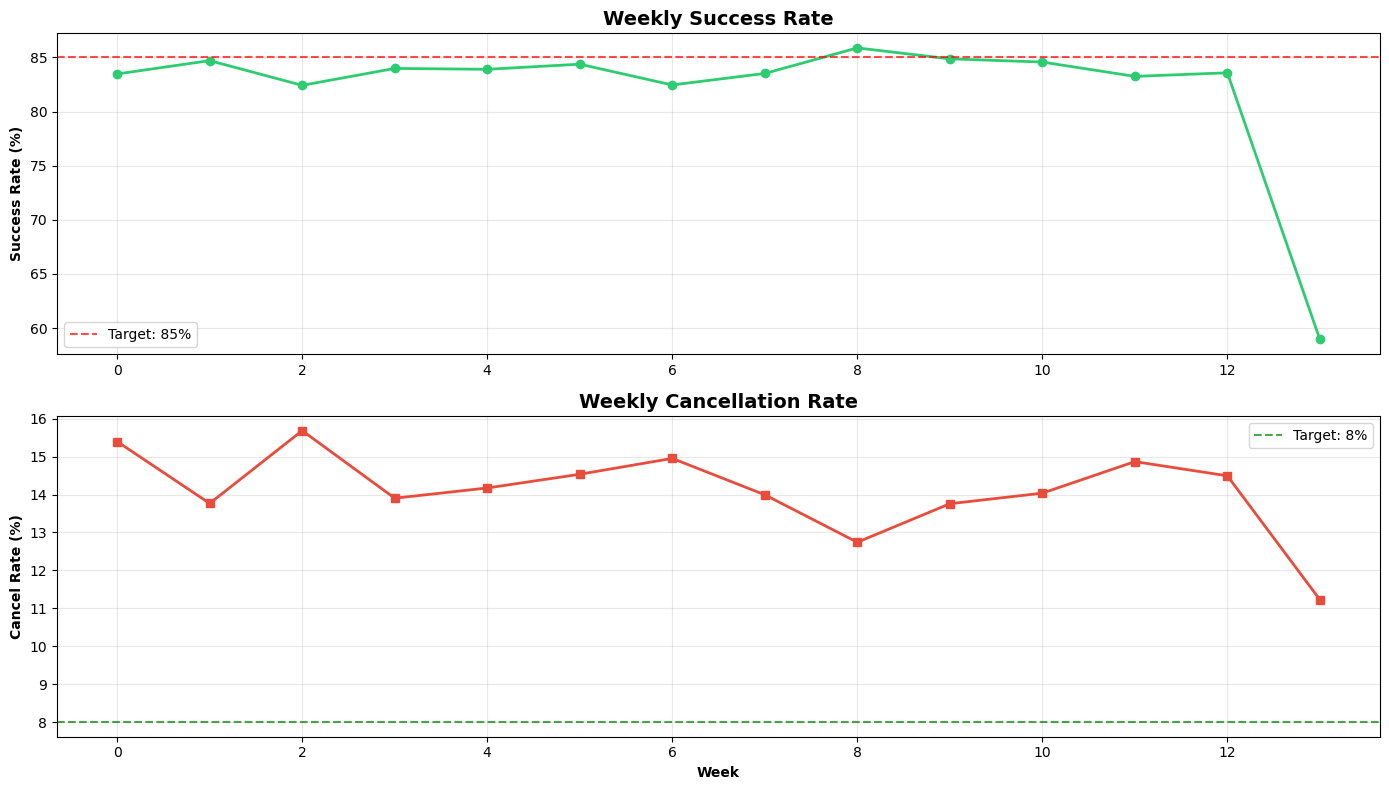

In [22]:
weekly = df.groupby(df['Date'].dt.to_period('W')).agg({
    'Order ID': 'count',
    'success': 'sum',
    'cancelled': 'sum',
    'Amount': 'sum'
})

weekly['success_rate'] = (weekly['success'] / weekly['Order ID'] * 100)
weekly['cancel_rate'] = (weekly['cancelled'] / weekly['Order ID'] * 100)

fig, ax = plt.subplots(2, 1, figsize=(14, 8))

# Success rate
ax[0].plot(range(len(weekly)), weekly['success_rate'], marker='o', linewidth=2, color='#2ecc71')
ax[0].axhline(85, color='red', linestyle='--', alpha=0.7, label='Target: 85%')
ax[0].set_title('Weekly Success Rate', fontsize=14, fontweight='bold')
ax[0].set_ylabel('Success Rate (%)', fontweight='bold')
ax[0].legend()
ax[0].grid(alpha=0.3)

# Cancellation rate
ax[1].plot(range(len(weekly)), weekly['cancel_rate'], marker='s', linewidth=2, color='#e74c3c')
ax[1].axhline(8, color='green', linestyle='--', alpha=0.7, label='Target: 8%')
ax[1].set_title('Weekly Cancellation Rate', fontsize=14, fontweight='bold')
ax[1].set_ylabel('Cancel Rate (%)', fontweight='bold')
ax[1].set_xlabel('Week', fontweight='bold')
ax[1].legend()
ax[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('weekly_trends.png', dpi=200)
plt.show()

In [23]:
# ============================================================================
# ANALYSIS 2: State Performance
# ============================================================================

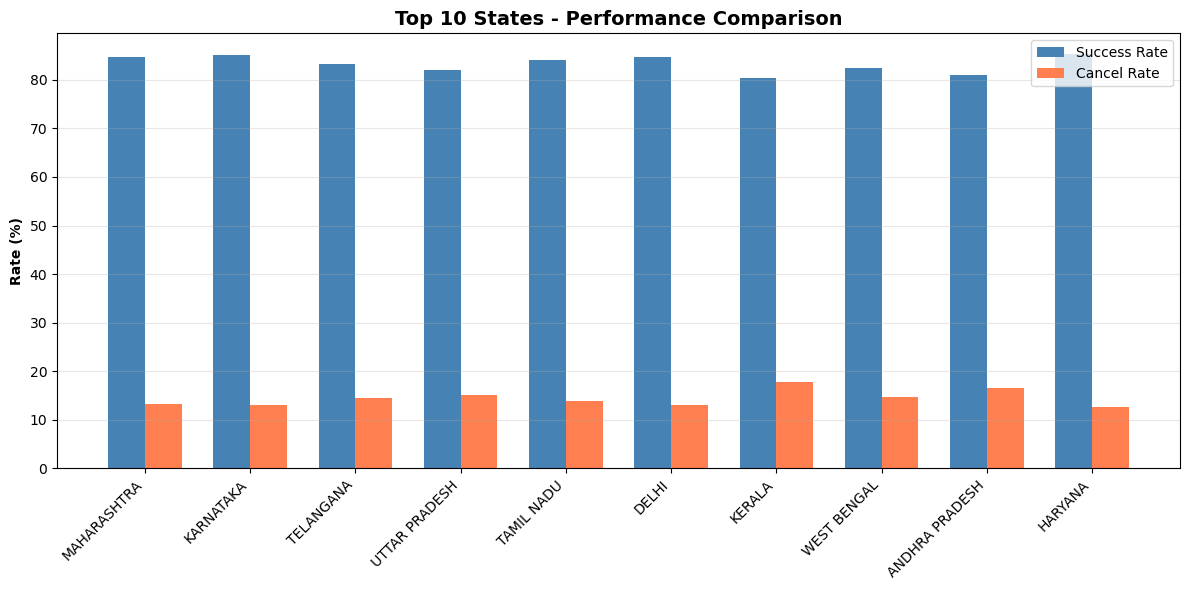

In [24]:
state_data = df.groupby('ship-state').agg({
    'Order ID': 'count',
    'success': 'mean',
    'cancelled': 'mean',
    'Amount': 'sum'
})

state_data['success_rate'] = state_data['success'] * 100
state_data['cancel_rate'] = state_data['cancelled'] * 100

top10 = state_data.nlargest(10, 'Amount')

fig, ax = plt.subplots(figsize=(12, 6))
x = range(len(top10))
width = 0.35

ax.bar([i - width/2 for i in x], top10['success_rate'], width, label='Success Rate', color='steelblue')
ax.bar([i + width/2 for i in x], top10['cancel_rate'], width, label='Cancel Rate', color='coral')

ax.set_title('Top 10 States - Performance Comparison', fontsize=14, fontweight='bold')
ax.set_ylabel('Rate (%)', fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(top10.index, rotation=45, ha='right')
ax.legend()
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('state_performance.png', dpi=200)
plt.show()

In [25]:
# ============================================================================
# ANALYSIS 3: Category Analysis
# ============================================================================

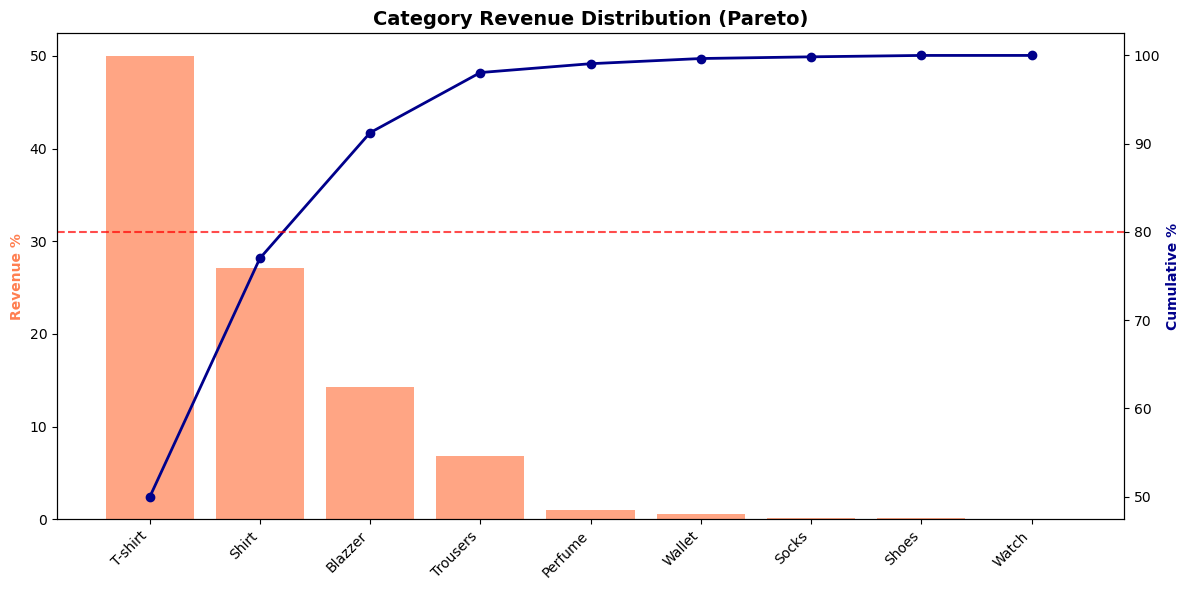

In [26]:
cat_data = df[df['Amount'].notna()].groupby('Category').agg({
    'Amount': 'sum',
    'Order ID': 'count'
}).sort_values('Amount', ascending=False)

cat_data['pct'] = cat_data['Amount'] / cat_data['Amount'].sum() * 100
cat_data['cumulative'] = cat_data['pct'].cumsum()

fig, ax = plt.subplots(figsize=(12, 6))
ax2 = ax.twinx()

# Bar chart
ax.bar(range(len(cat_data)), cat_data['pct'], color='coral', alpha=0.7)
ax.set_ylabel('Revenue %', fontweight='bold', color='coral')

# Line chart
ax2.plot(range(len(cat_data)), cat_data['cumulative'], marker='o', color='darkblue', linewidth=2)
ax2.axhline(80, color='red', linestyle='--', alpha=0.7)
ax2.set_ylabel('Cumulative %', fontweight='bold', color='darkblue')

ax.set_title('Category Revenue Distribution (Pareto)', fontsize=14, fontweight='bold')
ax.set_xticks(range(len(cat_data)))
ax.set_xticklabels(cat_data.index, rotation=45, ha='right')

plt.tight_layout()
plt.savefig('category_pareto.png', dpi=200)
plt.show()

In [27]:
# ============================================================================
# ANALYSIS 4: Fulfillment Comparison
# ============================================================================

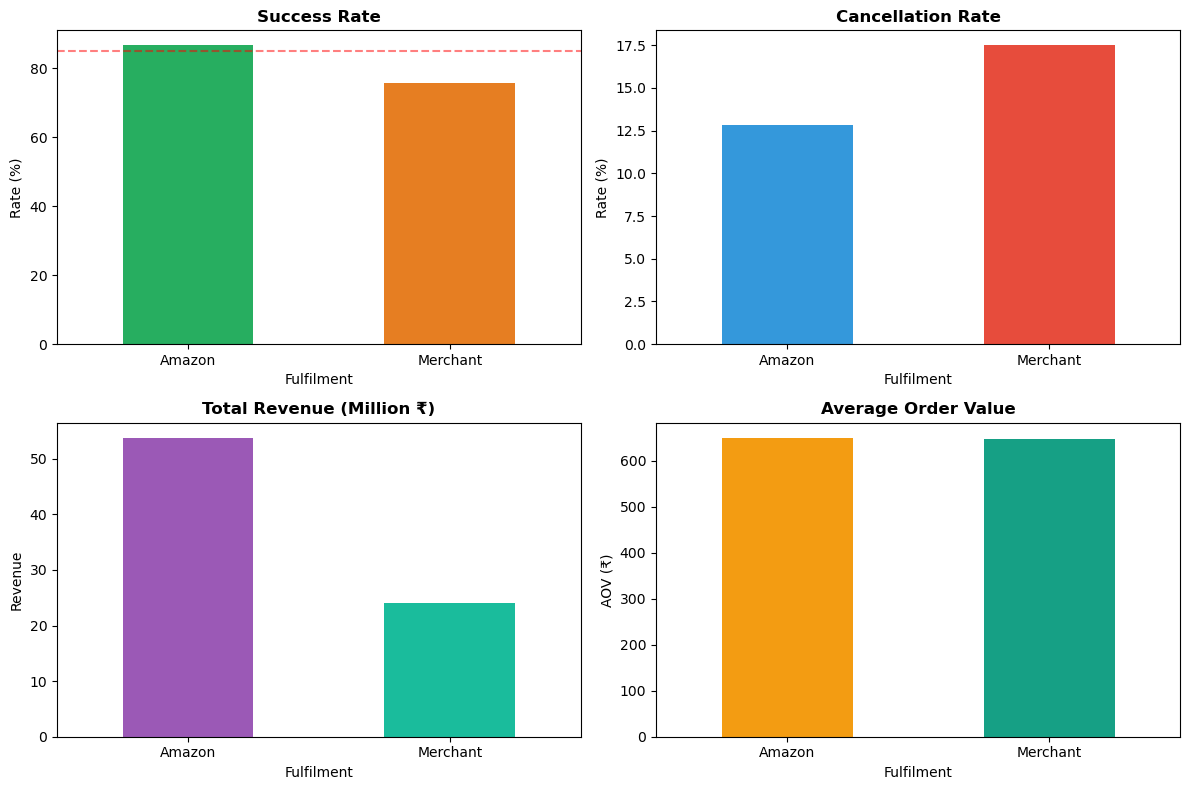

In [28]:
fulfill = df.groupby('Fulfilment').agg({
    'Order ID': 'count',
    'Amount': ['sum', 'mean'],
    'success': 'mean',
    'cancelled': 'mean'
})

fulfill.columns = ['orders', 'revenue', 'avg_order', 'success_rate', 'cancel_rate']
fulfill['success_rate'] *= 100
fulfill['cancel_rate'] *= 100

fig, ax = plt.subplots(2, 2, figsize=(12, 8))

# Success rate
fulfill['success_rate'].plot(kind='bar', ax=ax[0,0], color=['#27ae60', '#e67e22'])
ax[0,0].set_title('Success Rate', fontweight='bold')
ax[0,0].set_ylabel('Rate (%)')
ax[0,0].axhline(85, color='red', linestyle='--', alpha=0.5)
ax[0,0].set_xticklabels(ax[0,0].get_xticklabels(), rotation=0)

# Cancel rate
fulfill['cancel_rate'].plot(kind='bar', ax=ax[0,1], color=['#3498db', '#e74c3c'])
ax[0,1].set_title('Cancellation Rate', fontweight='bold')
ax[0,1].set_ylabel('Rate (%)')
ax[0,1].set_xticklabels(ax[0,1].get_xticklabels(), rotation=0)

# Revenue
(fulfill['revenue']/1e6).plot(kind='bar', ax=ax[1,0], color=['#9b59b6', '#1abc9c'])
ax[1,0].set_title('Total Revenue (Million ₹)', fontweight='bold')
ax[1,0].set_ylabel('Revenue')
ax[1,0].set_xticklabels(ax[1,0].get_xticklabels(), rotation=0)

# AOV
fulfill['avg_order'].plot(kind='bar', ax=ax[1,1], color=['#f39c12', '#16a085'])
ax[1,1].set_title('Average Order Value', fontweight='bold')
ax[1,1].set_ylabel('AOV (₹)')
ax[1,1].set_xticklabels(ax[1,1].get_xticklabels(), rotation=0)

plt.tight_layout()
plt.savefig('fulfillment_comparison.png', dpi=200)
plt.show()

In [29]:
# ============================================================================
# ANALYSIS 5: Revenue Trend
# ============================================================================

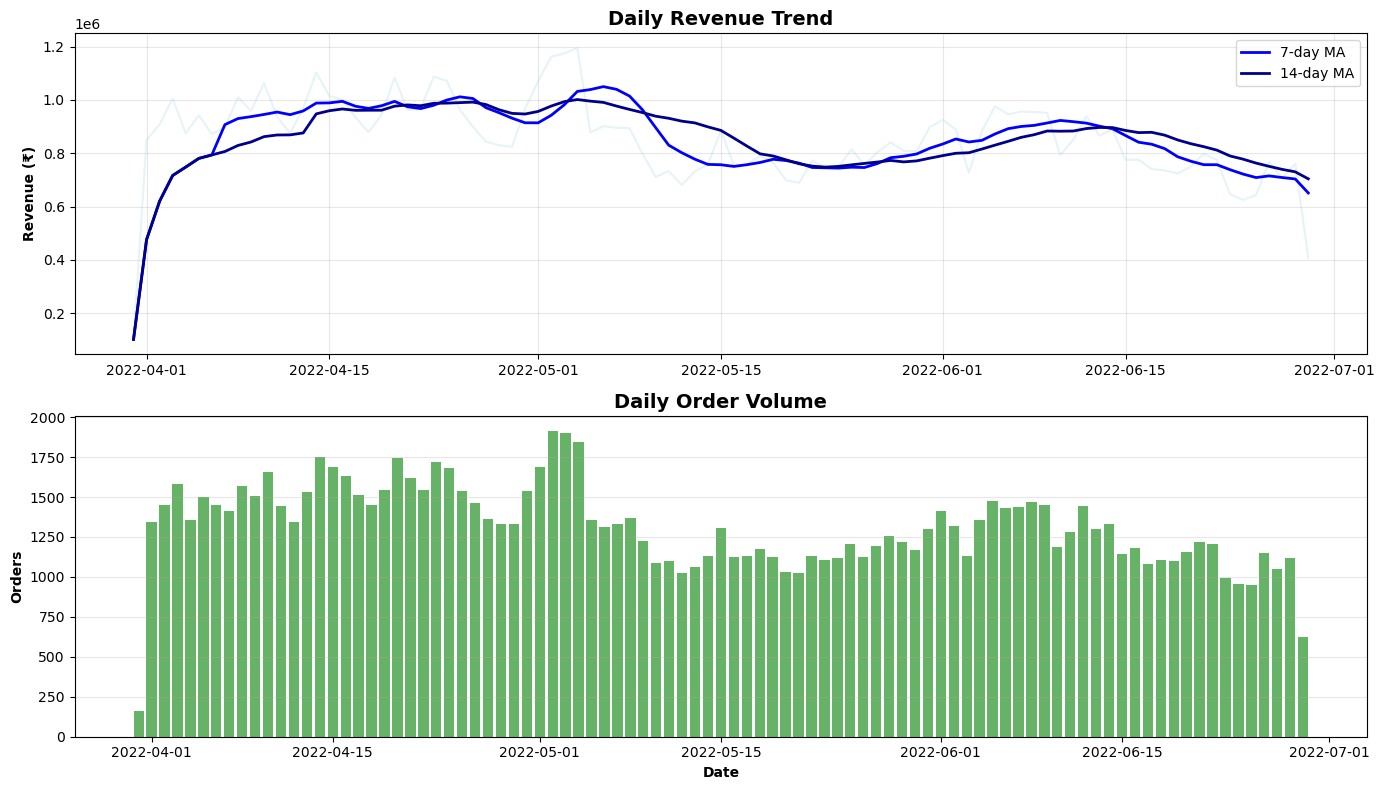

In [30]:
daily = df[df['Amount'].notna()].groupby('Date').agg({
    'Amount': 'sum',
    'Order ID': 'count'
})

daily['ma7'] = daily['Amount'].rolling(7, min_periods=1).mean()
daily['ma14'] = daily['Amount'].rolling(14, min_periods=1).mean()

fig, ax = plt.subplots(2, 1, figsize=(14, 8))

# Revenue
ax[0].plot(daily.index, daily['Amount'], alpha=0.3, color='lightblue')
ax[0].plot(daily.index, daily['ma7'], label='7-day MA', linewidth=2, color='blue')
ax[0].plot(daily.index, daily['ma14'], label='14-day MA', linewidth=2, color='darkblue')
ax[0].set_title('Daily Revenue Trend', fontsize=14, fontweight='bold')
ax[0].set_ylabel('Revenue (₹)', fontweight='bold')
ax[0].legend()
ax[0].grid(alpha=0.3)

# Orders
ax[1].bar(daily.index, daily['Order ID'], color='green', alpha=0.6)
ax[1].set_title('Daily Order Volume', fontsize=14, fontweight='bold')
ax[1].set_ylabel('Orders', fontweight='bold')
ax[1].set_xlabel('Date', fontweight='bold')
ax[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('revenue_trend.png', dpi=200)
plt.show()

In [31]:
# ============================================================================
# ANALYSIS 6: City Segmentation
# ============================================================================

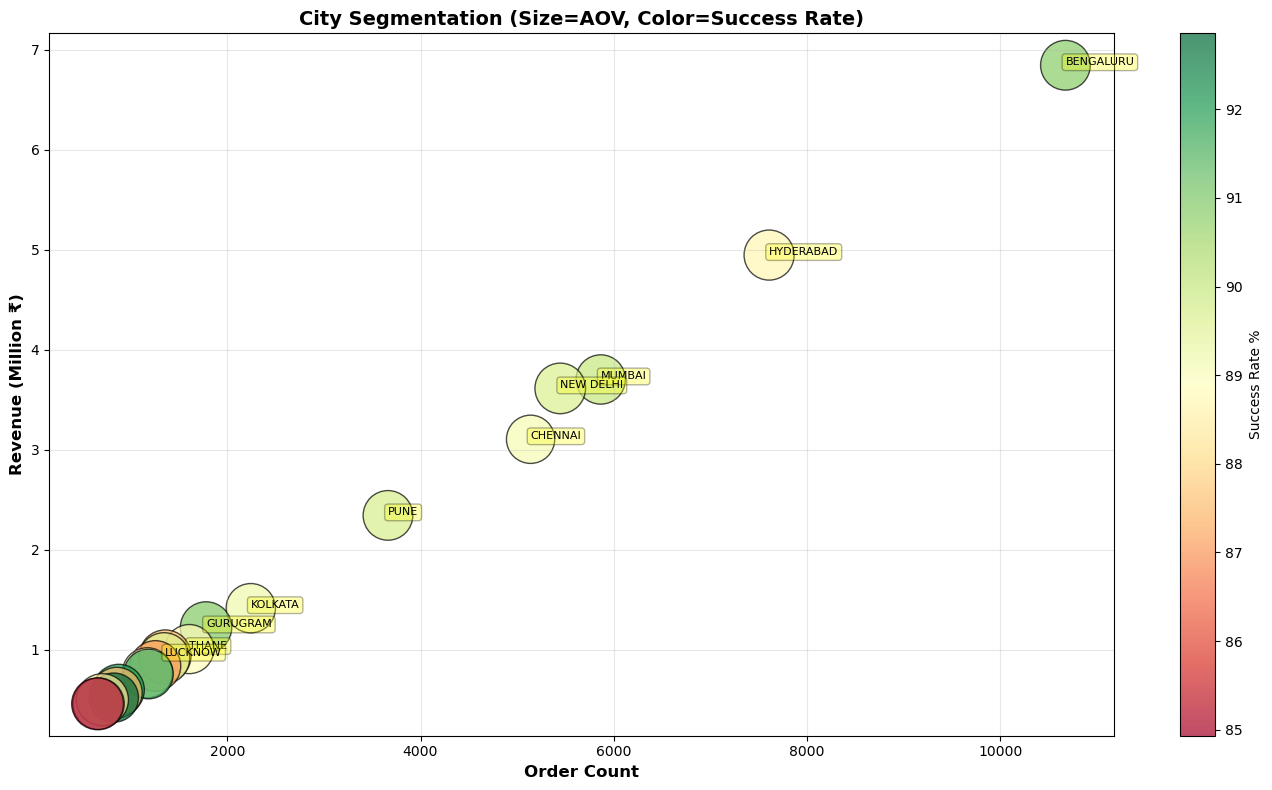

In [32]:
city = df[df['Amount'].notna()].groupby('ship-city').agg({
    'Order ID': 'count',
    'Amount': ['sum', 'mean'],
    'success': 'mean'
})

city.columns = ['orders', 'revenue', 'aov', 'success_rate']
city['success_rate'] *= 100

top20 = city.nlargest(20, 'revenue')

plt.figure(figsize=(14, 8))
scatter = plt.scatter(top20['orders'], top20['revenue']/1e6, 
                     s=top20['aov']*2, c=top20['success_rate'], 
                     cmap='RdYlGn', alpha=0.7, edgecolors='black')

for idx, city_name in enumerate(top20.index[:10]):  # Label top 10
    plt.annotate(city_name, (top20['orders'].iloc[idx], top20['revenue'].iloc[idx]/1e6),
                fontsize=8, bbox=dict(boxstyle='round,pad=0.3', facecolor='yellow', alpha=0.3))

plt.xlabel('Order Count', fontsize=12, fontweight='bold')
plt.ylabel('Revenue (Million ₹)', fontsize=12, fontweight='bold')
plt.title('City Segmentation (Size=AOV, Color=Success Rate)', fontsize=14, fontweight='bold')
plt.colorbar(scatter, label='Success Rate %')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('city_segmentation.png', dpi=200)
plt.show()

In [33]:
# ============================================================================
# ANALYSIS: Service Level Performance
# ============================================================================

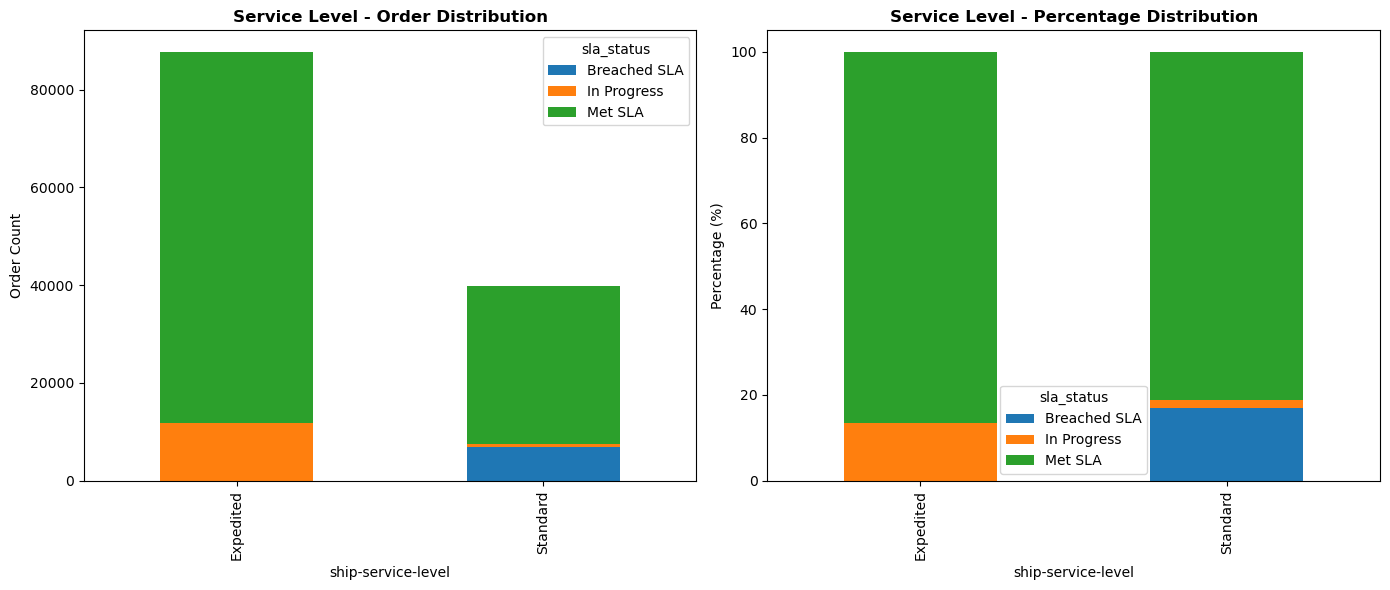

In [34]:
service = df.groupby(['ship-service-level', 'sla_status']).agg({
    'Order ID': 'count'
}).reset_index()

pivot_service = service.pivot(
    index='ship-service-level',
    columns='sla_status',
    values='Order ID'
).fillna(0)

pivot_service_pct = pivot_service.div(pivot_service.sum(axis=1), axis=0) * 100

fig, ax = plt.subplots(1, 2, figsize=(14, 6))

# Absolute
pivot_service.plot(kind='bar', stacked=True, ax=ax[0])
ax[0].set_title("Service Level - Order Distribution", fontweight='bold')
ax[0].set_ylabel("Order Count")

# Percentage
pivot_service_pct.plot(kind='bar', stacked=True, ax=ax[1])
ax[1].set_title("Service Level - Percentage Distribution", fontweight='bold')
ax[1].set_ylabel("Percentage (%)")

plt.tight_layout()
plt.savefig('service_level_analysis.png', dpi=200)
plt.show()

In [35]:
# ============================================================================
# Summary Stats
# ============================================================================

In [42]:
print("\n" + "="*60)
print("SUMMARY STATISTICS")
print("="*60)
print(f"Total Orders: {len(df):,}")
print(f"Total Revenue: ₹{df['Amount'].sum():,.0f}")
print(f"Avg Order Value: ₹{df['Amount'].mean():.0f}")
print(f"Success Rate: {df['success'].mean()*100:.1f}%")
print(f"Cancellation Rate: {df['cancelled'].mean()*100:.1f}%")
print(f"Return Rate: {df['returned'].mean()*100:.1f}%")
print(f"Revenue Loss (Cancelled): ₹{df['revenue_loss'].sum():,.0f}")
print("="*60)
print("\n📊 VISUALIZATIONS GENERATED:")
print("1. Cohort Analysis (Weekly Trends)")
print("2. State Performance Heatmap")
print("3. Category Pareto Analysis")
print("4. Fulfilment Type Comparison")
print("5. Service Level Performance")
print("6. Revenue Trend & Forecast")
print("7. City Segmentation (RFM-style)")
print("\n📁FILES CREATED:")
print("Amazon_Orders_Enriched.csv (for Power BI import)")
print("7 visualization PNG files")


SUMMARY STATISTICS
Total Orders: 128,976
Total Revenue: ₹77,765,433
Avg Order Value: ₹649
Success Rate: 82.5%
Cancellation Rate: 14.1%
Return Rate: 1.6%
Revenue Loss (Cancelled): ₹6,848,199

📊 VISUALIZATIONS GENERATED:
1. Cohort Analysis (Weekly Trends)
2. State Performance Heatmap
3. Category Pareto Analysis
4. Fulfilment Type Comparison
5. Service Level Performance
6. Revenue Trend & Forecast
7. City Segmentation (RFM-style)

📁FILES CREATED:
Amazon_Orders_Enriched.csv (for Power BI import)
7 visualization PNG files


In [43]:
# Export for Power BI
output_cols = ['Order ID', 'Date', 'Status', 'Fulfilment', 'ship-service-level',
               'Category', 'Courier Status', 'Qty', 'Amount', 'ship-city', 'ship-state',
               'B2B', 'delivered', 'cancelled', 'returned', 'revenue_loss', 'city_tier',
               'product_group', 'week', 'month', 'success', 'days_old']

df[output_cols].to_csv('amazon_enriched.csv', index=False)
print("\nEnriched data exported: amazon_enriched.csv")
print("Visualizations saved as PNG files")


Enriched data exported: amazon_enriched.csv
Visualizations saved as PNG files
